# Лабораторная работа №3

## Изучение временного ряда солнечной активности и подбор параметров SARIMA

Работа выполнена по структуре лекционного ноутбука: загрузка ряда, STL-декомпозиция, проверка стационарности ADF-тестом, подбор параметров по ACF/PACF.


## 1. Импорт библиотек


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)


## 2. Загрузка предобработанных данных из лабораторной работы №2

Загружаем обучающую и тестовую выборки. Для дальнейшего анализа используем только обучающий ряд, как требуется в задании.


In [2]:
target_col = 'Sunspots'

candidate_train_paths = [
    Path('Analyze/lab_2/sunspots_train_preprocessed.csv'),
    Path('../lab_2/sunspots_train_preprocessed.csv'),
]
candidate_test_paths = [
    Path('Analyze/lab_2/sunspots_test_preprocessed.csv'),
    Path('../lab_2/sunspots_test_preprocessed.csv'),
]

train_path = next(path for path in candidate_train_paths if path.exists())
test_path = next(path for path in candidate_test_paths if path.exists())

train = pd.read_csv(train_path, parse_dates=['Month']).sort_values('Month').reset_index(drop=True)
test = pd.read_csv(test_path, parse_dates=['Month']).sort_values('Month').reset_index(drop=True)

# В лабораторной работе №2 квадратичная интерполяция дала два небольших отрицательных значения.
# Так как число солнечных пятен физически не может быть отрицательным, заменяем их на 0.
negative_count = int((train[target_col] < 0).sum())
negative_test_count = int((test[target_col] < 0).sum())
if negative_count > 0:
    train[target_col] = train[target_col].clip(lower=0)
if negative_test_count > 0:
    test[target_col] = test[target_col].clip(lower=0)

series = train.set_index('Month')[target_col].astype(float).asfreq('MS')
test_series = test.set_index('Month')[target_col].astype(float).asfreq('MS')

print('train shape:', train.shape)
print('test shape:', test.shape)
print('train range:', train['Month'].min().date(), '->', train['Month'].max().date())
print('test range:', test['Month'].min().date(), '->', test['Month'].max().date())
print('Пропущенные значения в train:', train[target_col].isna().sum())
print('Отрицательные значения исправлены:', negative_count)

display(train.head())


train shape: (2115, 4)
test shape: (705, 4)
train range: 1749-01-01 -> 1925-03-01
test range: 1925-04-01 -> 1983-12-01
Пропущенные значения в train: 0
Отрицательные значения исправлены: 2


,Month,Sunspots,Sunspots_raw,Sunspots_interpolated
0,1749-01-01,58.0,58.0,58.0
1,1749-02-01,62.6,62.6,62.6
2,1749-03-01,70.0,70.0,70.0
3,1749-04-01,55.7,55.7,55.7
4,1749-05-01,85.0,85.0,85.0


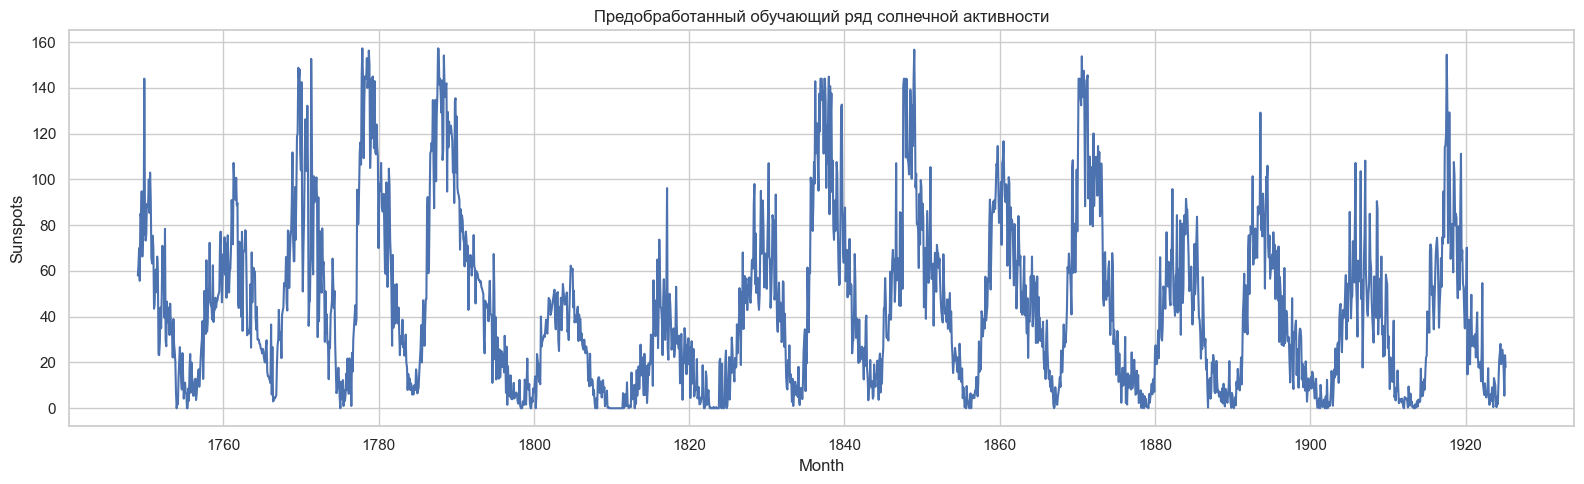

In [3]:
plt.figure(figsize=(16, 5))
sns.lineplot(data=train, x='Month', y=target_col)
plt.title('Предобработанный обучающий ряд солнечной активности')
plt.xlabel('Month')
plt.ylabel('Sunspots')
plt.tight_layout()
plt.show()


## 3. STL-декомпозиция временного ряда

Для солнечной активности характерен цикл около 11 лет. Так как данные месячные, сезонный/циклический лаг равен:

`s = 11 * 12 = 132` месяца.


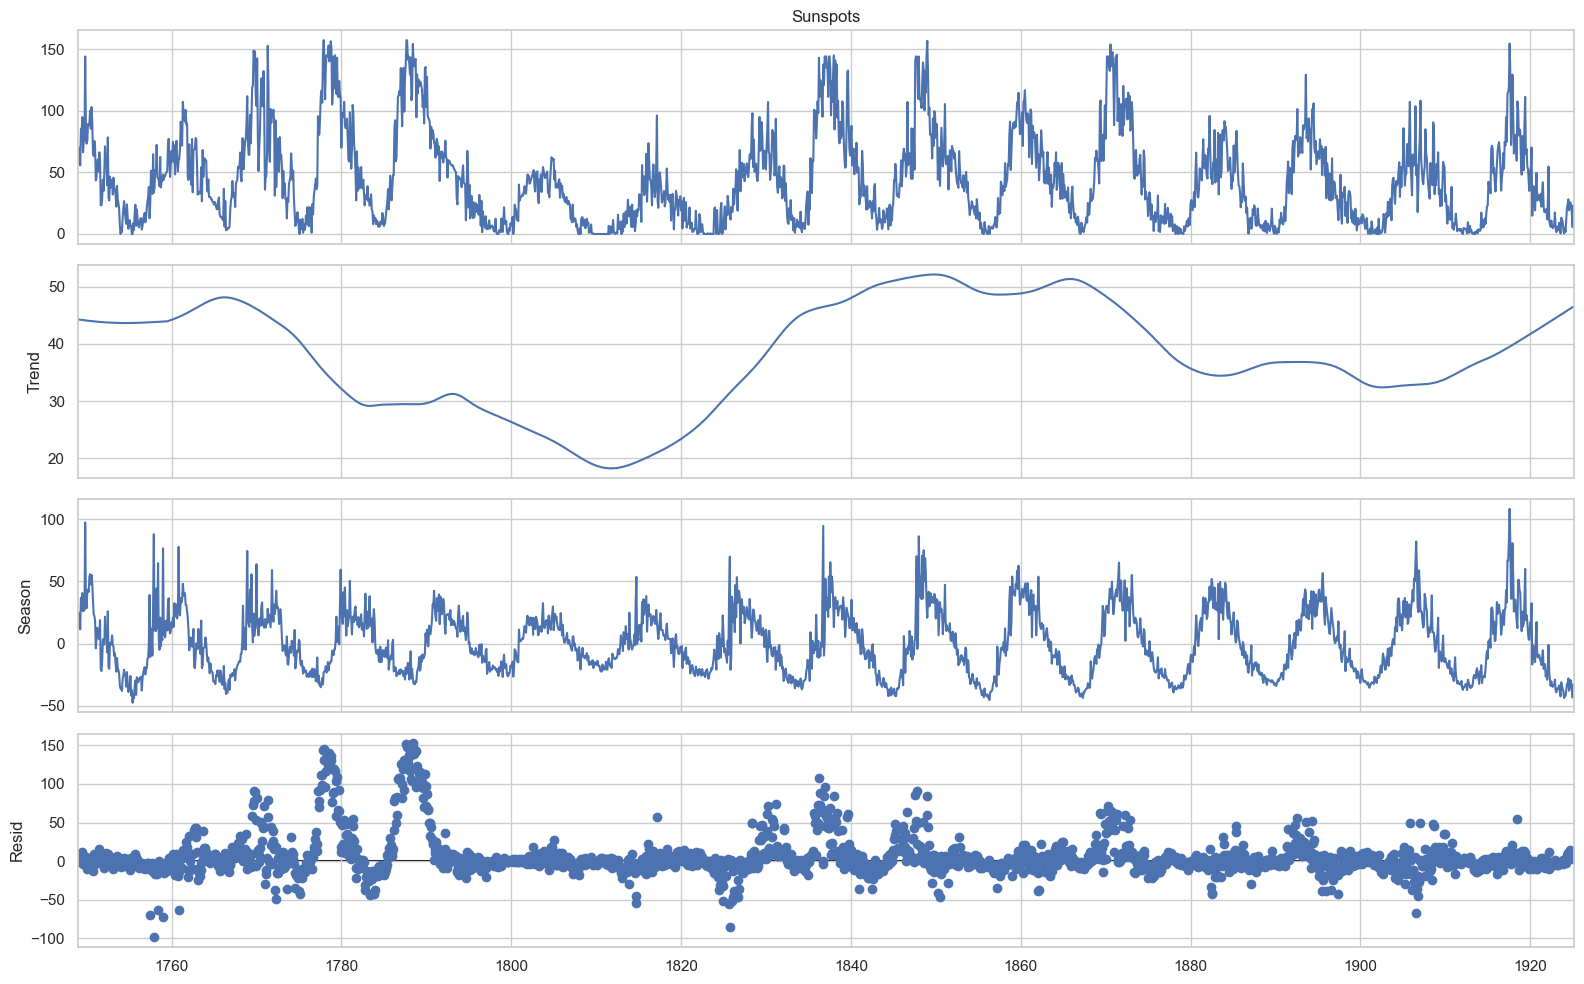

In [4]:
s = 132

stl = STL(series, period=s, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(16, 10)
plt.tight_layout()
plt.show()


In [5]:
seasonal_strength = max(
    0,
    1 - stl_result.resid.var() / (stl_result.seasonal + stl_result.resid).var(),
)
trend_strength = max(
    0,
    1 - stl_result.resid.var() / (stl_result.trend + stl_result.resid).var(),
)
seasonal_amplitude = stl_result.seasonal.max() - stl_result.seasonal.min()

print(f'Сила циклической компоненты: {seasonal_strength:.3f}')
print(f'Сила тренда: {trend_strength:.3f}')
print(f'Размах циклической компоненты: {seasonal_amplitude:.2f}')


Сила циклической компоненты: 0.406
Сила тренда: 0.106
Размах циклической компоненты: 155.84


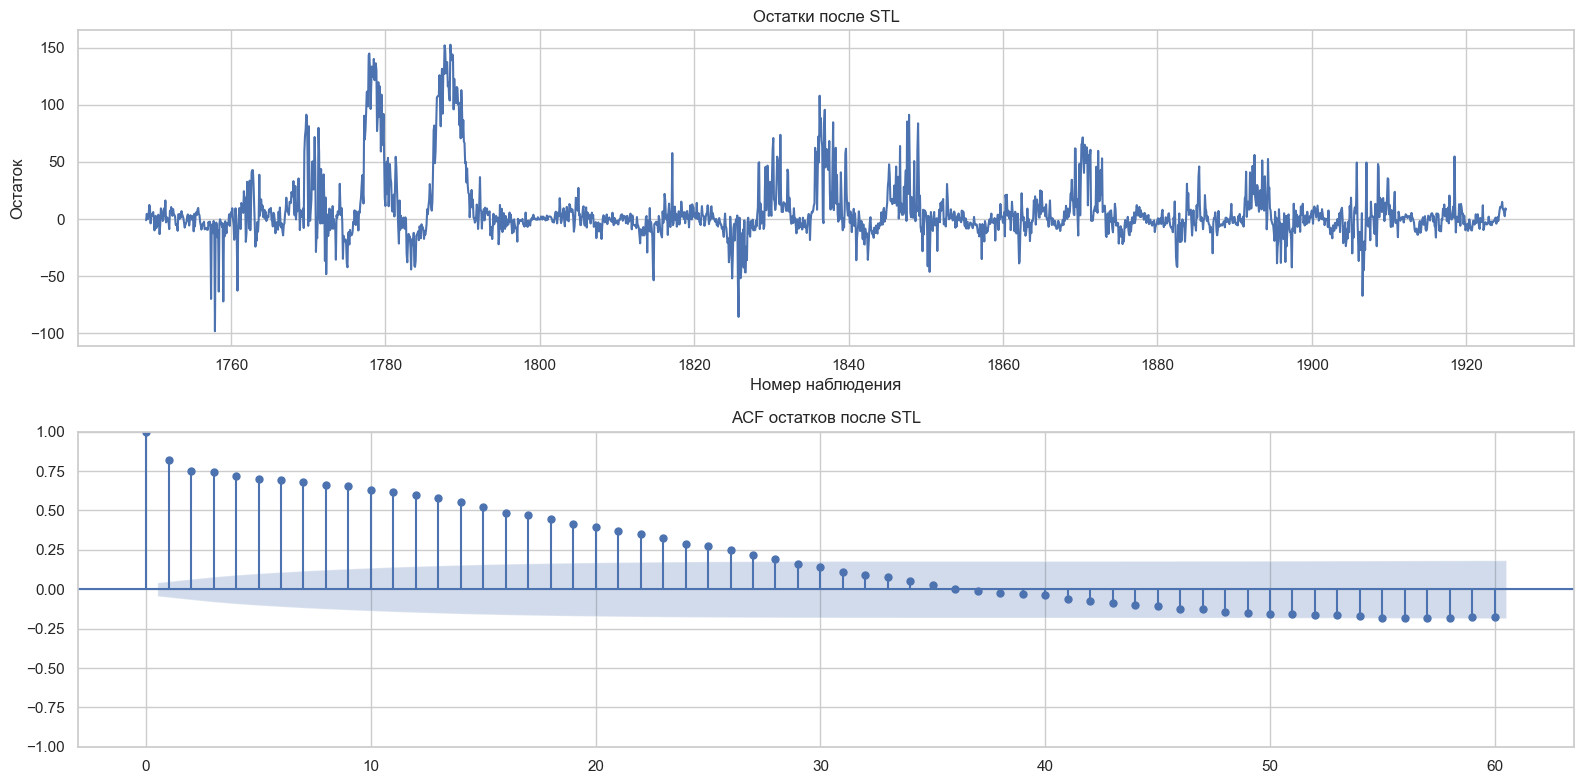

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(stl_result.resid)
axes[0].set_title('Остатки после STL')
axes[0].set_xlabel('Номер наблюдения')
axes[0].set_ylabel('Остаток')

plot_acf(stl_result.resid, lags=60, ax=axes[1])
axes[1].set_title('ACF остатков после STL')
plt.tight_layout()
plt.show()


### Вывод по STL

В ряде наблюдается выраженная цикличность примерно на `132` месяца, то есть около `11` лет. Тренд присутствует, но он слабее циклической компоненты. Остатки после STL не выглядят полностью случайными: на графике ACF остаются значимые автокорреляции. Поэтому для дальнейшего прогноза подходит модель семейства `SARIMA`.


## 4. Исследование стационарности и подбор `d`, `D`

Используем тест Дики-Фуллера. Если `p-value < 0.05`, ряд считаем стационарным. Для SARIMA сначала проверяем сезонное дифференцирование.


In [7]:
def adf_pvalue(x: pd.Series) -> float:
    return adfuller(x.dropna(), autolag='AIC')[1]

stationarity = pd.DataFrame([
    {'d': 0, 'D': 0, 'series': 'исходный ряд', 'adf_pvalue': adf_pvalue(series)},
    {'d': 0, 'D': 1, 'series': f'сезонное diff({s})', 'adf_pvalue': adf_pvalue(series.diff(s))},
    {'d': 1, 'D': 0, 'series': 'обычное diff(1)', 'adf_pvalue': adf_pvalue(series.diff())},
    {'d': 1, 'D': 1, 'series': f'сезонное diff({s}) + обычное diff(1)', 'adf_pvalue': adf_pvalue(series.diff(s).diff())},
])

stationarity['stationary'] = stationarity['adf_pvalue'] < 0.05
display(stationarity)

d = 0
D = 0
print('Выбранные параметры дифференцирования:')
print('d =', d)
print('D =', D)


,d,D,series,adf_pvalue,stationary
0,0,0,исходный ряд,1.567851e-11,True
1,0,1,сезонное diff(132),1.135002e-09,True
2,1,0,обычное diff(1),2.782022e-12,True
3,1,1,сезонное diff(132) + обычное diff(1),2.910095e-14,True


Выбранные параметры дифференцирования:
d = 0
D = 0


### Вывод по стационарности

ADF-тест показывает, что исходный обучающий ряд уже стационарен: `p-value < 0.05`. Поэтому дополнительное дифференцирование не требуется, выбираем `d = 0`, `D = 0`.

Сезонное дифференцирование тоже даёт стационарный ряд, но оно было бы лишним, потому что исходный ряд уже прошёл ADF-тест.


## 5. Подбор `p`, `q`, `P`, `Q` по ACF и PACF

Так как `d = 0` и `D = 0`, параметры подбираем по графикам ACF/PACF исходного обучающего ряда.


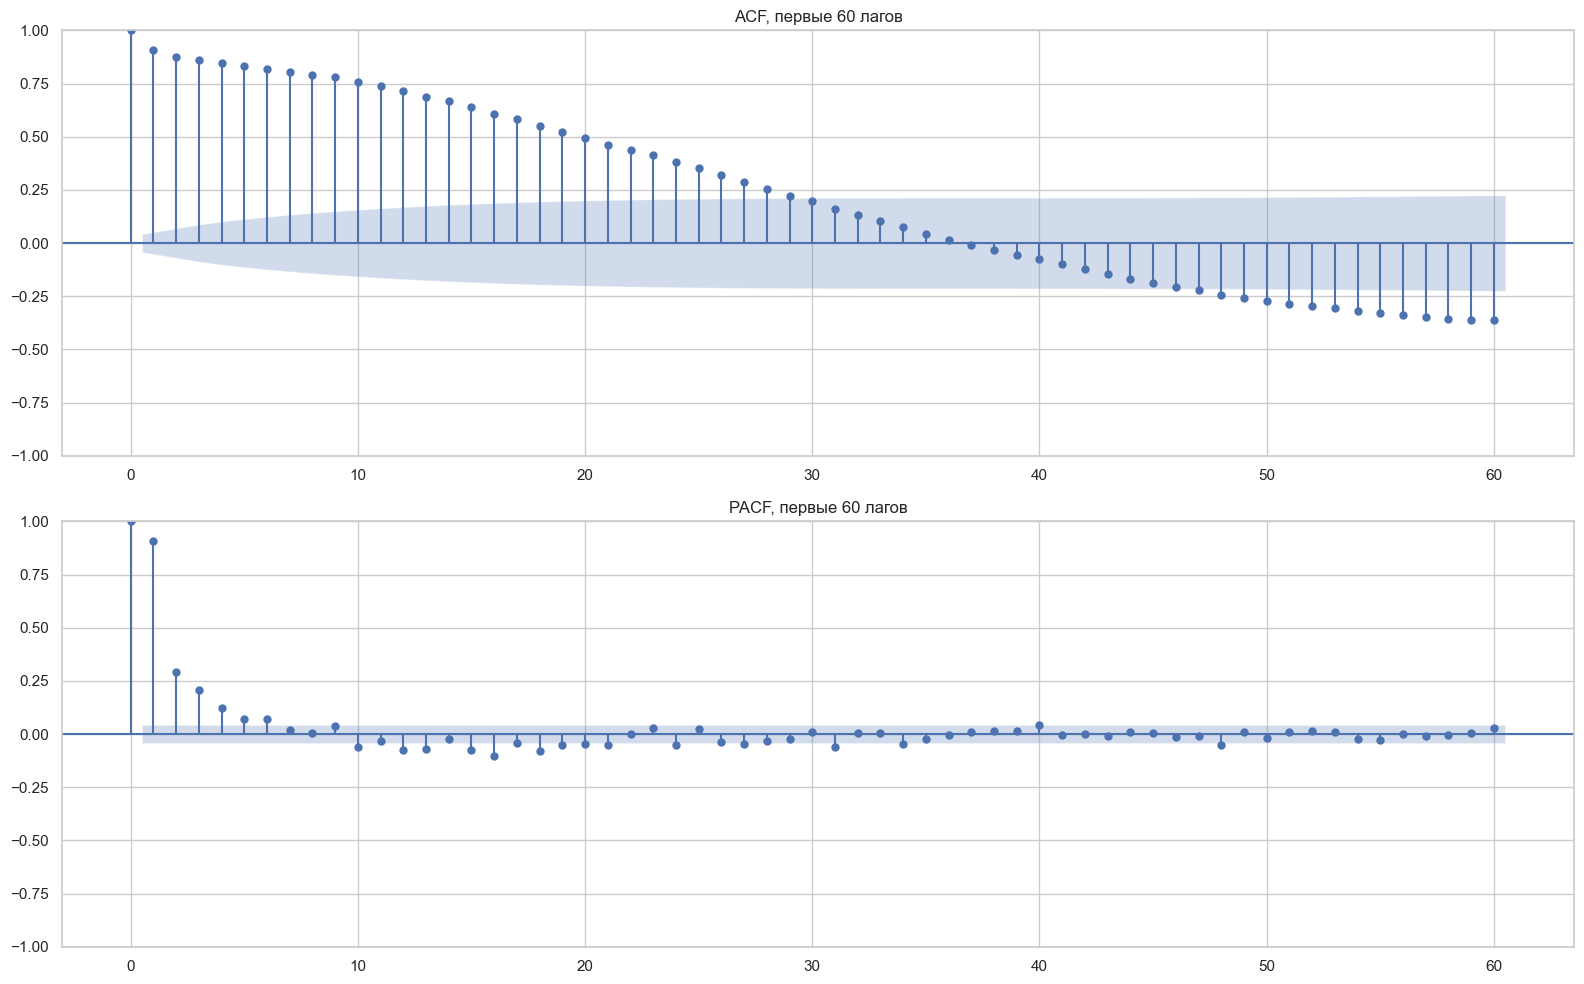

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(series, lags=60, ax=axes[0])
axes[0].set_title('ACF, первые 60 лагов')
plot_pacf(series, lags=60, method='ywm', ax=axes[1])
axes[1].set_title('PACF, первые 60 лагов')
plt.tight_layout()
plt.show()


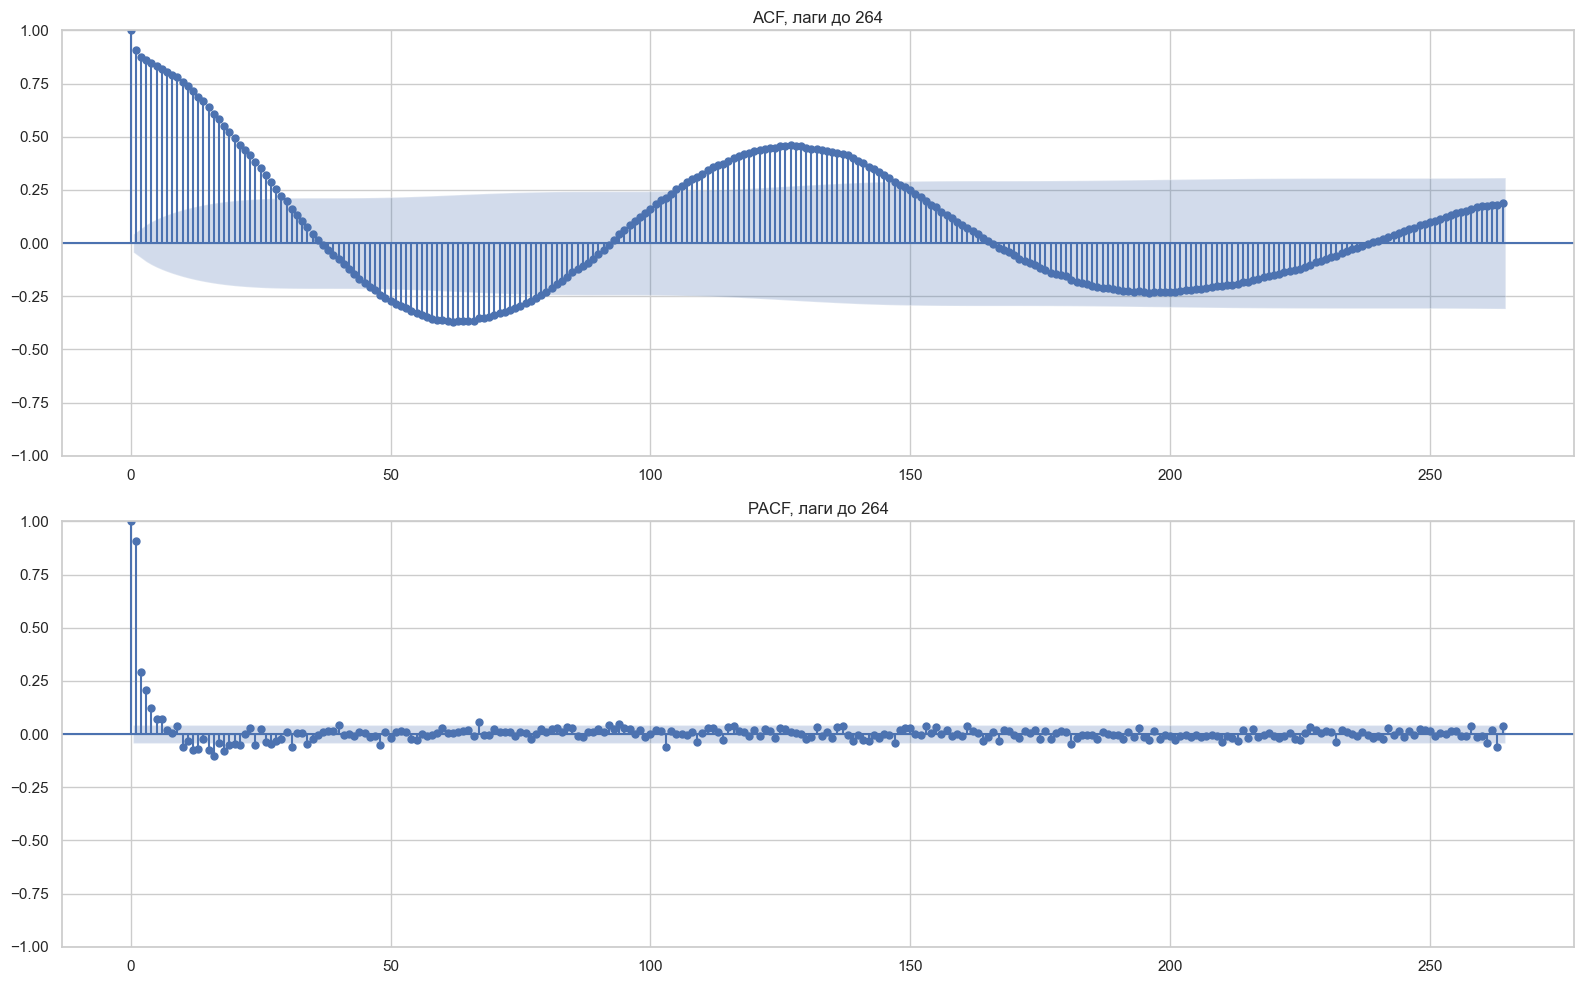

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(series, lags=2 * s, ax=axes[0])
axes[0].set_title(f'ACF, лаги до {2 * s}')
plot_pacf(series, lags=2 * s, method='ywm', ax=axes[1])
axes[1].set_title(f'PACF, лаги до {2 * s}')
plt.tight_layout()
plt.show()


In [10]:
acf_values = acf(series, nlags=2 * s, fft=True)
pacf_values = pacf(series, nlags=2 * s, method='ywm')
ci95 = 1.96 / np.sqrt(len(series))

selected_lags = [1, 2, 3, 4, 5, 6, 7, s]
acf_pacf_table = pd.DataFrame({
    'lag': selected_lags,
    'acf': [acf_values[lag] for lag in selected_lags],
    'pacf': [pacf_values[lag] for lag in selected_lags],
})
acf_pacf_table['acf_significant'] = acf_pacf_table['acf'].abs() > ci95
acf_pacf_table['pacf_significant'] = acf_pacf_table['pacf'].abs() > ci95

display(acf_pacf_table.round({'acf': 4, 'pacf': 4}))
print(f'Граница значимости около: +/- {ci95:.4f}')


,lag,acf,pacf,acf_significant,pacf_significant
0,1,0.9068,0.9068,True,True
1,2,0.8739,0.2906,True,True
2,3,0.8592,0.2059,True,True
3,4,0.8453,0.1225,True,True
4,5,0.8305,0.0702,True,True
5,6,0.8200,0.0694,True,True
6,7,0.8052,0.0196,True,False
7,132,0.4440,0.0313,True,False


Граница значимости около: +/- 0.0426


In [11]:
p = 6
q = 0
P = 0
Q = 1

print('Выбранные параметры модели:')
print(f'p = {p}, q = {q}')
print(f'P = {P}, Q = {Q}, s = {s}')


Выбранные параметры модели:
p = 6, q = 0
P = 0, Q = 1, s = 132


### Вывод по ACF/PACF

На малых лагах ACF затухает постепенно, а PACF имеет заметные значимые значения на лагах `1-6`. Поэтому выбираем AR-компоненту `p = 6` и не добавляем обычную MA-компоненту: `q = 0`.

На циклическом лаге `s = 132` ACF значима, а PACF незначима. Это соответствует циклической MA-компоненте, поэтому выбираем `Q = 1`, `P = 0`.


## 6. Обучение модели SARIMA

Обучаем модель, выбранную по графикам ACF/PACF:

`SARIMA(6, 0, 0) x (0, 0, 1, 132)`

Так как сезонный лаг большой, обучение может занимать заметное время, поэтому запуск ячейки ниже можно включать отдельно.


In [12]:
RUN_SLOW_SARIMA = True

model_type = 'SARIMA'
order = (p, d, q)
seasonal_order = (P, D, Q, s)

if RUN_SLOW_SARIMA:
    start_time = time.perf_counter()

    sarima_model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    )

    sarima_result = sarima_model.fit(method='lbfgs', maxiter=200, disp=False)
    sarima_fit_time = time.perf_counter() - start_time

    sarima_forecast = sarima_result.get_forecast(steps=len(test_series))
    sarima_pred = sarima_forecast.predicted_mean
    sarima_ci = sarima_forecast.conf_int()

    sarima_pred.index = test_series.index
    sarima_ci.index = test_series.index

    sarima_metrics = pd.DataFrame({
        'model': ['SARIMA'],
        'MAE': [mean_absolute_error(test_series, sarima_pred)],
        'RMSE': [np.sqrt(mean_squared_error(test_series, sarima_pred))],
        'fit_time_min': [sarima_fit_time / 60],
    })

    display(sarima_metrics.round(3))
    print(sarima_result.summary())
else:
    sarima_pred = None
    sarima_ci = None
    print('Обучение SARIMA пропущено. Для запуска установите RUN_SLOW_SARIMA = True.')


,model,MAE,RMSE,fit_time_min
0,SARIMA,42.777,52.715,3.505


                                       SARIMAX Results                                       
Dep. Variable:                              Sunspots   No. Observations:                 2115
Model:             SARIMAX(6, 0, 0)x(0, 0, [1], 132)   Log Likelihood               -8088.609
Date:                               Thu, 07 May 2026   AIC                          16195.218
Time:                                       11:53:39   BIC                          16245.545
Sample:                                   01-01-1749   HQIC                         16213.706
                                        - 03-01-1925   Scale                          205.207
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.7551      0.752      2.333      0.020       0.281       3.229
ar.L1      

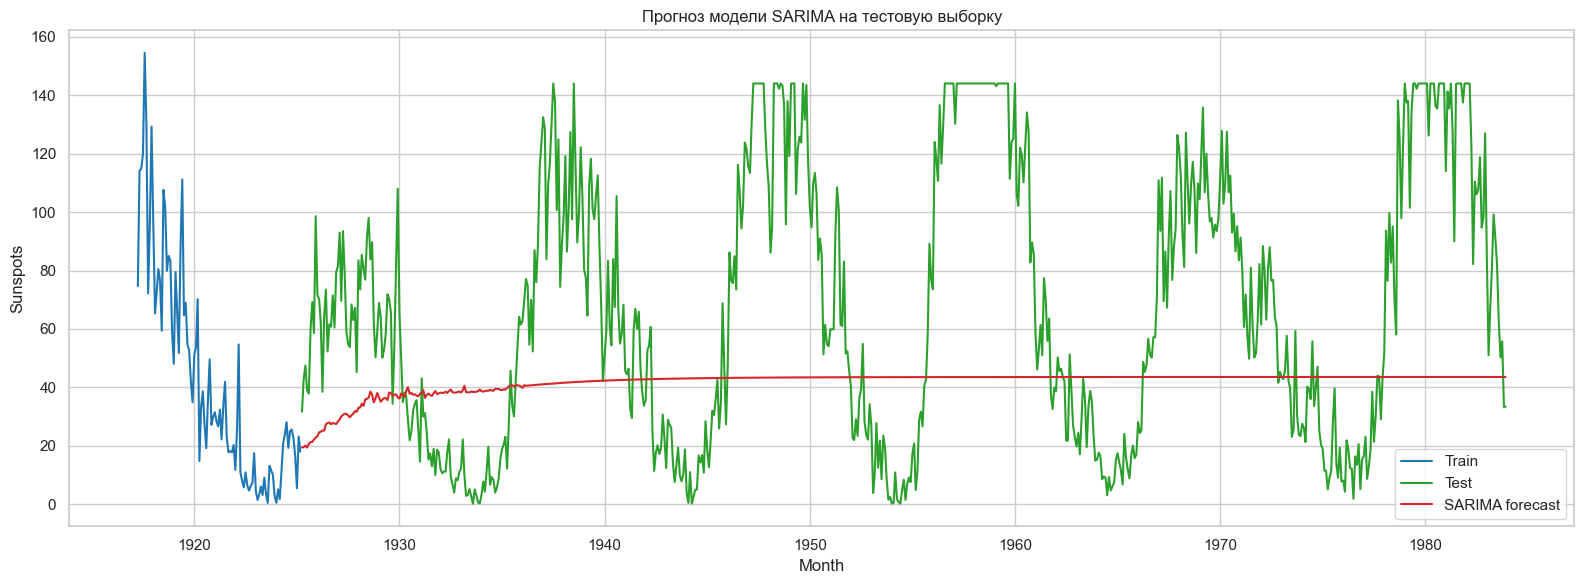

In [13]:
if RUN_SLOW_SARIMA:
    tail_months = 8 * 12
    plot_train = series.iloc[-tail_months:]

    plt.figure(figsize=(16, 6))
    plt.plot(plot_train.index, plot_train, label='Train', color='tab:blue')
    plt.plot(test_series.index, test_series, label='Test', color='tab:green')
    plt.plot(sarima_pred.index, sarima_pred, label='SARIMA forecast', color='tab:red')
    plt.title('Прогноз модели SARIMA на тестовую выборку')
    plt.xlabel('Month')
    plt.ylabel('Sunspots')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('График прогноза будет построен после обучения модели SARIMA.')


## 7. Финальные параметры

`model_type = "SARIMA"`

`(p, d, q) = (6, 0, 0)`

`(P, D, Q, s) = (0, 0, 1, 132)`

Итоговая модель для дальнейшего прогнозирования:

`SARIMA(6, 0, 0) x (0, 0, 1, 132)`
